In [1]:
import jupyter_black
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
#df = pd.read_excel('Fz_Rfg Substitute Meat_POS_2020(EDITED).xlsx')
data = pd.read_excel('2023_Other_Brand_Data.xlsx')

In [3]:
data.head(50)

,Geography,Time,Product,Brand Franchise Name,Brand Name,Meat Source,Product Type,Flavour,Total Ounces,UPC 13 digit,...,Incremental Volume,Incremental Dollars,ACV Weighted Distribution,ACV Weighted Distribution No Merch,ACV Weighted Distribution Any Merch,ACV Weighted Distribution Price Reductions Only,ACV Weighted Distribution Feature Only,ACV Weighted Distribution Display Only,ACV Weighted Distribution Special Pack Only,ACV Weighted Distribution Feature and Display
0,Total US - Multi Outlet + Conv,Week Ending 01-08-23,GARDEIN FROZEN ITALIAN MEAT SUBSTITUTE PATTY 8...,GARDEIN,GARDEIN,ITALIAN,MEAT SUBSTITUTE,ITALIAN,8,842234002241,...,132.616247,514.046728,1.259343,0.834487,0.424857,0.424857,NaN,NaN,NaN,NaN
1,Total US - Multi Outlet + Conv,Week Ending 01-08-23,GARDEIN FROZEN ORIGINAL MEAT SUBSTITUTE BREAKF...,GARDEIN,GARDEIN,ORIGINAL,MEAT SUBSTITUTE,ORIGINAL,8,842234003311,...,20.718943,65.562339,0.567528,0.376817,0.190711,0.176870,0.013841,NaN,NaN,NaN
2,Total US - Multi Outlet + Conv,Week Ending 01-08-23,GARDEIN FROZEN REGULAR MEAT SUBSTITUTE BURGER ...,GARDEIN,GARDEIN,REGULAR,MEAT SUBSTITUTE,REGULAR,12,842234000821,...,527.180616,2548.870469,8.622840,6.132039,2.490801,0.746187,1.693925,0.050688,NaN,NaN
3,Total US - Multi Outlet + Conv,Week Ending 01-08-23,GARDEIN FROZEN REGULAR MEAT SUBSTITUTE SLIDER ...,GARDEIN,GARDEIN,REGULAR,MEAT SUBSTITUTE,REGULAR,10,842234001171,...,NaN,NaN,0.065145,0.065145,NaN,NaN,NaN,NaN,NaN,NaN
4,Total US - Multi Outlet + Conv,Week Ending 01-08-23,GARDEIN FROZEN SPICY MEAT SUBSTITUTE BREAKFAST...,GARDEIN,GARDEIN,SPICY,MEAT SUBSTITUTE,SPICY,8,842234003321,...,0.000000,0.000000,0.201466,0.199031,0.002435,0.002435,NaN,NaN,NaN,NaN
5,Total US - Multi Outlet + Conv,Week Ending 01-08-23,GARDEIN ULTIMATE PLANT BASED FROZEN REGULAR ME...,GARDEIN,GARDEIN ULTIMATE PLANT BASED,REGULAR,MEAT SUBSTITUTE,REGULAR,8,842234007121,...,351.978638,2284.013176,17.706434,14.143065,3.563369,2.491959,0.948196,0.123213,NaN,NaN
6,Total US - Multi Outlet + Conv,Week Ending 01-08-23,DR PRAEGERS FROZEN CHICKEN MEAT SUBSTITUTE BUR...,DR PRAEGERS,DR PRAEGERS,CHICKEN,MEAT SUBSTITUTE,CHICKEN,8,80868029061,...,26.785456,137.777726,3.313421,2.869495,0.443926,0.443926,NaN,NaN,NaN,NaN
7,Total US - Multi Outlet + Conv,Week Ending 01-08-23,DR PRAEGERS FROZEN REGULAR MEAT SUBSTITUTE BUR...,DR PRAEGERS,DR PRAEGERS,REGULAR,MEAT SUBSTITUTE,REGULAR,8,80868029071,...,108.232170,502.697217,4.398264,3.691472,0.706792,0.697788,NaN,0.009003,NaN,NaN
8,Total US - Multi Outlet + Conv,Week Ending 01-08-23,MORNINGSTAR FARMS FROZEN ORIGINAL MEAT SUBSTIT...,MORNINGSTAR FARMS,MORNINGSTAR FARMS,ORIGINAL,MEAT SUBSTITUTE,ORIGINAL,8,28989100881,...,8105.965059,53877.005228,35.981745,18.138808,17.842937,2.786988,12.466942,0.840480,NaN,1.748528
9,Total US - Multi Outlet + Conv,Week Ending 01-08-23,MORNINGSTAR FARMS FROZEN ORIGINAL MEAT SUBSTIT...,MORNINGSTAR FARMS,MORNINGSTAR FARMS,ORIGINAL,MEAT SUBSTITUTE,ORIGINAL,8,28989971401,...,28.634764,282.090314,0.433104,0.373706,0.059398,0.059398,NaN,NaN,NaN,NaN


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19810 entries, 0 to 19809
Data columns (total 64 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Geography                                        19810 non-null  object 
 1   Time                                             19810 non-null  object 
 2   Product                                          19810 non-null  object 
 3   Brand Franchise Name                             19810 non-null  object 
 4   Brand Name                                       19810 non-null  object 
 5   Meat Source                                      19810 non-null  object 
 6   Product Type                                     19810 non-null  object 
 7   Flavour                                          19810 non-null  object 
 8   Total Ounces                                     19810 non-null  int64  
 9   UPC 13 digit                

In [5]:
data.isnull().sum().head(30)

Geography                                 0
Time                                      0
Product                                   0
Brand Franchise Name                      0
Brand Name                                0
Meat Source                               0
Product Type                              0
Flavour                                   0
Total Ounces                              0
UPC 13 digit                              0
Unit Sales                                0
Unit Sales No Merch                     414
Unit Sales Any Merch                   6361
Unit Sales Price Reductions Only       7248
Unit Sales Feature Only               17015
Unit Sales Display Only               14274
Unit Sales Special Pack Only          19810
Unit Sales Feature and Display        18807
Volume Sales                              0
Volume Sales No Merch                   414
Volume Sales Any Merch                 6361
Volume Sales Price Reductions Only     7248
Volume Sales Feature Only       

# MISSING VALUES

In [ ]:
columns_to_drop = ['Time', 'Brand Name', 'Flavour', 'Volume Sales', 'Unit Sales', 
                   'Base Volume Sales', 'Base Unit Sales', 'Base Dollar Sales', 
                   'Price per Volume']

data_clean = data_clean.drop(columns_to_drop, axis=1)

In [6]:
data_clean = data.loc[:, data.isnull().sum() == 0]
data_clean = data_clean.drop('Time', axis=1)
data_clean = data_clean.drop('Brand Name', axis=1)
data_clean = data_clean.drop('Flavour', axis=1)
data_clean = data_clean.drop('Volume Sales', axis=1)
data_clean = data_clean.drop('Unit Sales', axis=1)
data_clean = data_clean.drop('Base Volume Sales', axis=1)
data_clean = data_clean.drop('Base Unit Sales', axis=1)
data_clean = data_clean.drop('Base Dollar Sales', axis=1)
data_clean = data_clean.drop('Price per Volume', axis=1)

In [7]:
data_clean.head(30)

,Geography,Product,Brand Franchise Name,Meat Source,Product Type,Total Ounces,UPC 13 digit,Dollar Sales,Price per Unit,ACV Weighted Distribution
0,Total US - Multi Outlet + Conv,GARDEIN FROZEN ITALIAN MEAT SUBSTITUTE PATTY 8...,GARDEIN,ITALIAN,MEAT SUBSTITUTE,8,842234002241,3611.486671,4.042058,1.259343
1,Total US - Multi Outlet + Conv,GARDEIN FROZEN ORIGINAL MEAT SUBSTITUTE BREAKF...,GARDEIN,ORIGINAL,MEAT SUBSTITUTE,8,842234003311,1796.081223,4.476425,0.567528
2,Total US - Multi Outlet + Conv,GARDEIN FROZEN REGULAR MEAT SUBSTITUTE BURGER ...,GARDEIN,REGULAR,MEAT SUBSTITUTE,12,842234000821,29891.658049,5.248054,8.622840
3,Total US - Multi Outlet + Conv,GARDEIN FROZEN REGULAR MEAT SUBSTITUTE SLIDER ...,GARDEIN,REGULAR,MEAT SUBSTITUTE,10,842234001171,508.545582,6.738523,0.065145
4,Total US - Multi Outlet + Conv,GARDEIN FROZEN SPICY MEAT SUBSTITUTE BREAKFAST...,GARDEIN,SPICY,MEAT SUBSTITUTE,8,842234003321,667.819234,5.348025,0.201466
5,Total US - Multi Outlet + Conv,GARDEIN ULTIMATE PLANT BASED FROZEN REGULAR ME...,GARDEIN,REGULAR,MEAT SUBSTITUTE,8,842234007121,54827.425979,5.130456,17.706434
6,Total US - Multi Outlet + Conv,DR PRAEGERS FROZEN CHICKEN MEAT SUBSTITUTE BUR...,DR PRAEGERS,CHICKEN,MEAT SUBSTITUTE,8,80868029061,7155.678862,5.288542,3.313421
7,Total US - Multi Outlet + Conv,DR PRAEGERS FROZEN REGULAR MEAT SUBSTITUTE BUR...,DR PRAEGERS,REGULAR,MEAT SUBSTITUTE,8,80868029071,8649.184879,4.939059,4.398264
8,Total US - Multi Outlet + Conv,MORNINGSTAR FARMS FROZEN ORIGINAL MEAT SUBSTIT...,MORNINGSTAR FARMS,ORIGINAL,MEAT SUBSTITUTE,8,28989100881,285613.508548,4.608237,35.981745
9,Total US - Multi Outlet + Conv,MORNINGSTAR FARMS FROZEN ORIGINAL MEAT SUBSTIT...,MORNINGSTAR FARMS,ORIGINAL,MEAT SUBSTITUTE,8,28989971401,8596.589334,5.317179,0.433104


In [8]:
data_clean

,Geography,Product,Brand Franchise Name,Meat Source,Product Type,Total Ounces,UPC 13 digit,Dollar Sales,Price per Unit,ACV Weighted Distribution
0,Total US - Multi Outlet + Conv,GARDEIN FROZEN ITALIAN MEAT SUBSTITUTE PATTY 8...,GARDEIN,ITALIAN,MEAT SUBSTITUTE,8,842234002241,3611.486671,4.042058,1.259343
1,Total US - Multi Outlet + Conv,GARDEIN FROZEN ORIGINAL MEAT SUBSTITUTE BREAKF...,GARDEIN,ORIGINAL,MEAT SUBSTITUTE,8,842234003311,1796.081223,4.476425,0.567528
2,Total US - Multi Outlet + Conv,GARDEIN FROZEN REGULAR MEAT SUBSTITUTE BURGER ...,GARDEIN,REGULAR,MEAT SUBSTITUTE,12,842234000821,29891.658049,5.248054,8.622840
3,Total US - Multi Outlet + Conv,GARDEIN FROZEN REGULAR MEAT SUBSTITUTE SLIDER ...,GARDEIN,REGULAR,MEAT SUBSTITUTE,10,842234001171,508.545582,6.738523,0.065145
4,Total US - Multi Outlet + Conv,GARDEIN FROZEN SPICY MEAT SUBSTITUTE BREAKFAST...,GARDEIN,SPICY,MEAT SUBSTITUTE,8,842234003321,667.819234,5.348025,0.201466
...,...,...,...,...,...,...,...,...,...,...
19805,West - Standard - Multi Outlet + Conv,LIGHTLIFE SMART GROUND REFRIGERATED ORIGINAL M...,LIGHTLIFE,ORIGINAL,MEAT SUBSTITUTE,12,43454100151,3206.219885,5.342122,8.134034
19806,West - Standard - Multi Outlet + Conv,PRIVATE LABEL REFRIGERATED REGULAR MEAT SUBSTI...,PRIVATE LABEL,REGULAR,MEAT SUBSTITUTE,8,629248472,25.215194,4.888096,0.085062
19807,West - Standard - Multi Outlet + Conv,PRIVATE LABEL REFRIGERATED REGULAR MEAT SUBSTI...,PRIVATE LABEL,REGULAR,MEAT SUBSTITUTE,12,914512376,169.840000,5.661333,0.259323
19808,West - Standard - Multi Outlet + Conv,PRIVATE LABEL REFRIGERATED REGULAR MEAT SUBSTI...,PRIVATE LABEL,REGULAR,MEAT SUBSTITUTE,8,322637841,69.180000,3.843333,0.255215


In [9]:
# Encoding categorical variables using one-hot encoding
categorical_cols = data_clean.select_dtypes(include=['object']).columns
data_encoded = pd.get_dummies(data_clean, columns=categorical_cols, drop_first=True)

# Display the information of the cleaned and encoded dataset
data_encoded.info(), data_encoded.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19810 entries, 0 to 19809
Columns: 104 entries, Total Ounces to Product Type_POULTRY SUBSTITUTE
dtypes: float64(3), int64(2), uint8(99)
memory usage: 2.6 MB


(None,
    Total Ounces  UPC 13 digit  Dollar Sales  Price per Unit  \
 0             8  842234002241   3611.486671        4.042058   
 1             8  842234003311   1796.081223        4.476425   
 2            12  842234000821  29891.658049        5.248054   
 3            10  842234001171    508.545582        6.738523   
 4             8  842234003321    667.819234        5.348025   
 
    ACV Weighted Distribution  \
 0                   1.259343   
 1                   0.567528   
 2                   8.622840   
 3                   0.065145   
 4                   0.201466   
 
    Geography_Great Lakes - Standard - Multi Outlet + Conv  \
 0                                                  0        
 1                                                  0        
 2                                                  0        
 3                                                  0        
 4                                                  0        
 
    Geography_Mid-South - Standar

# OUTLIERS

# CORRELATION MATRIX

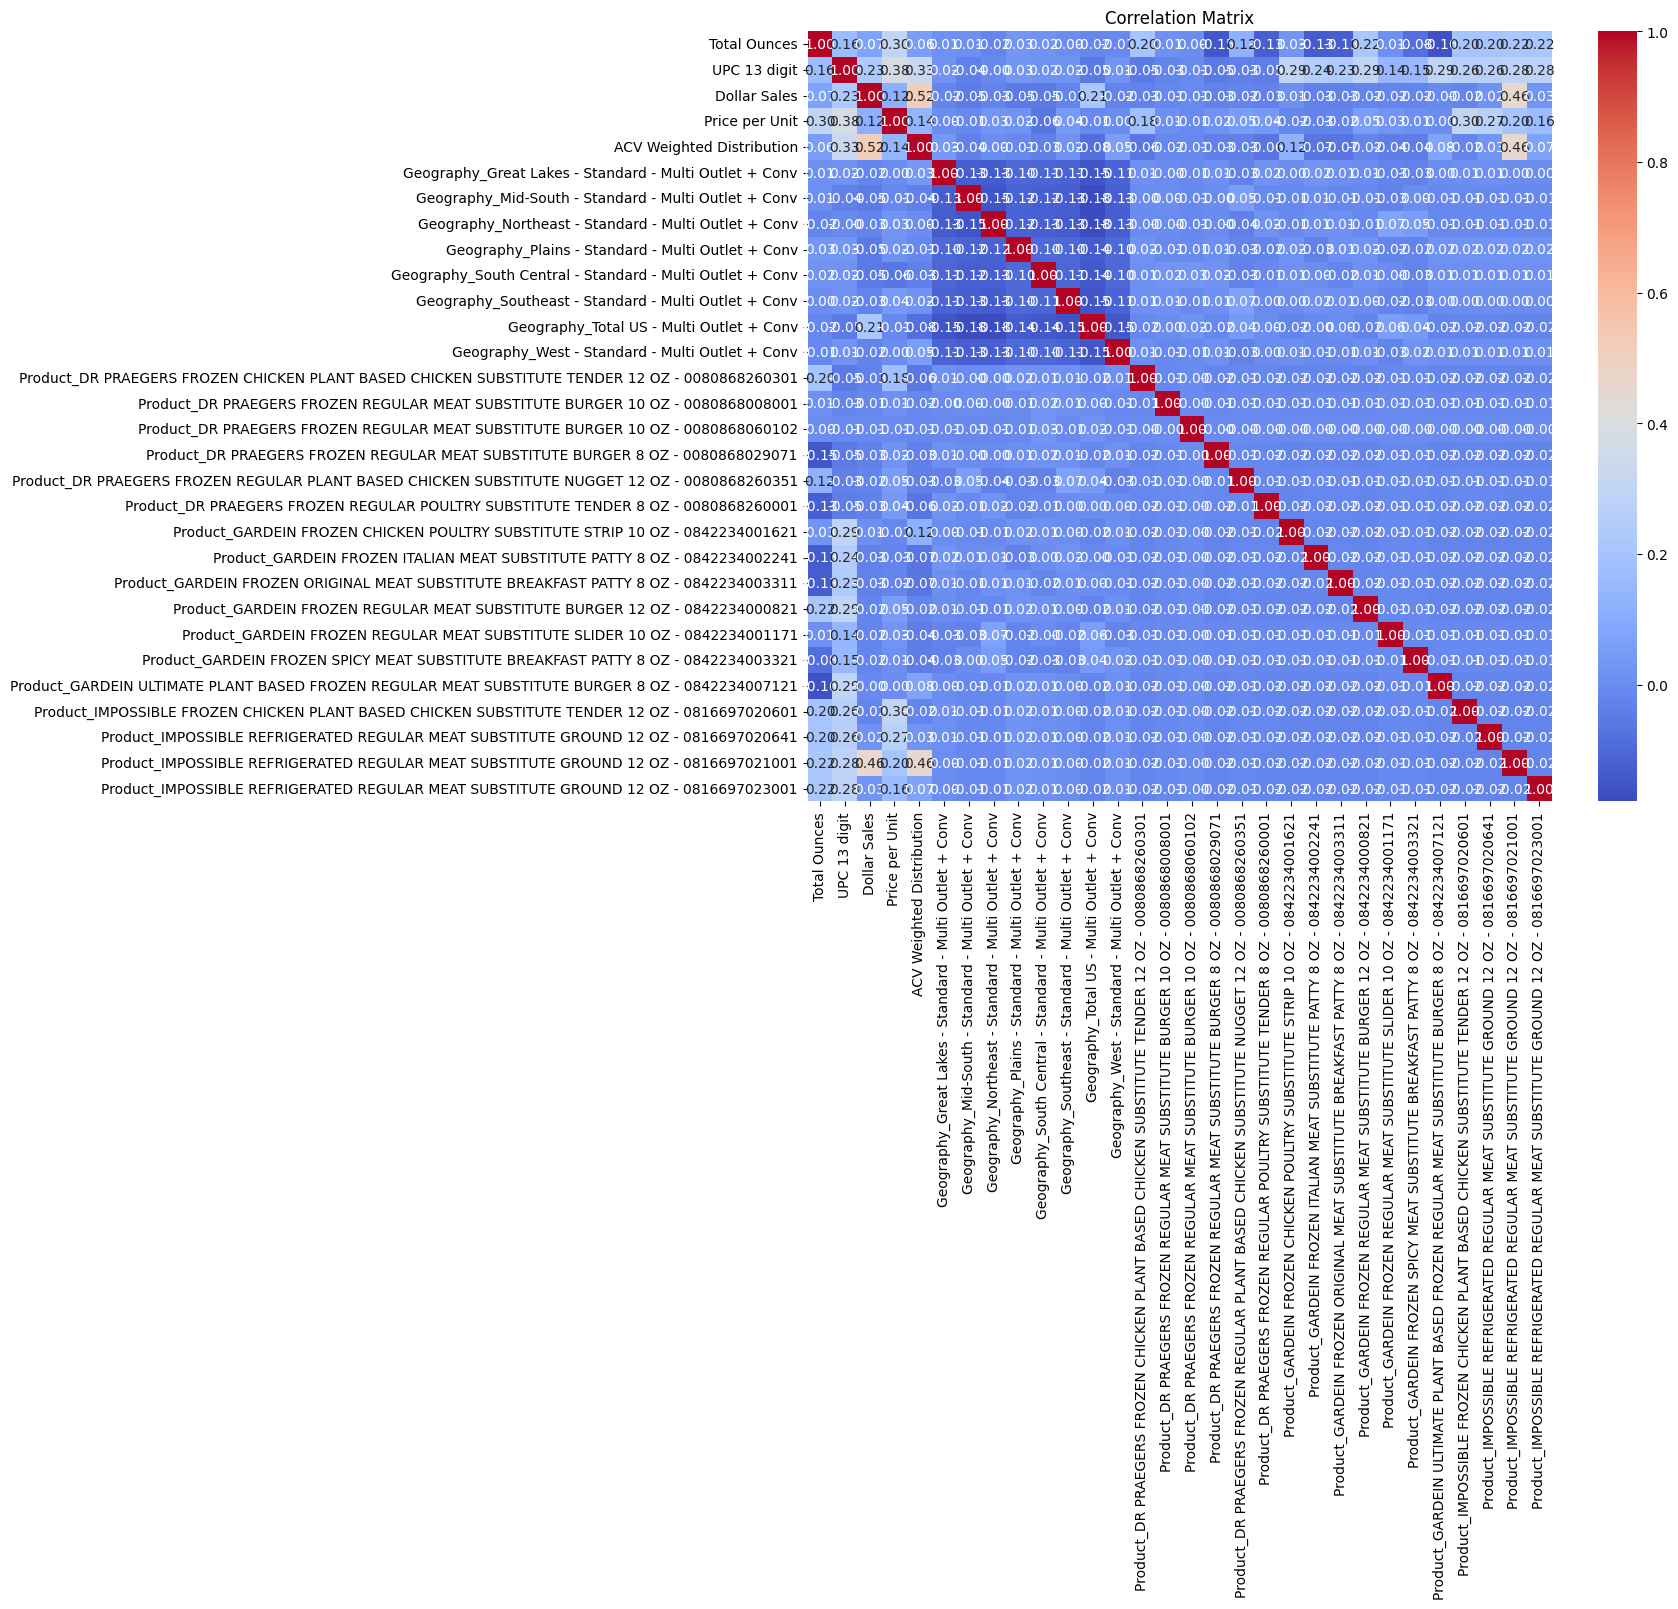

In [10]:
# Calculating the correlation matrix for a subset of columns (first 30 columns to avoid overloading visualization)
correlation_matrix = data_encoded.iloc[:, :30].corr()

# Plotting the heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Selecting numeric columns for VIF calculation
numeric_cols = data_encoded.select_dtypes(include=['float64', 'int64']).columns



In [12]:
# Checking for NaN values in the dataset and replacing them with the mean of each column
data_encoded = data_encoded.fillna(data_encoded.mean())

# Re-calculating VIF after handling NaNs
vif_data = pd.DataFrame({
    "Feature": numeric_cols,
    "VIF": [variance_inflation_factor(data_encoded[numeric_cols].values, i) for i in range(len(numeric_cols))]
})

# Displaying the updated VIF values
vif_data.sort_values(by="VIF", ascending=False)

,Feature,VIF
1,UPC 13 digit,1.723533
4,ACV Weighted Distribution,1.455205
2,Dollar Sales,1.375202
3,Price per Unit,1.145177
0,Total Ounces,0.346674


In [13]:
# Calculating VIF for each variable in the dataset
vif_data = pd.DataFrame({
    "Feature": numeric_cols,
    "VIF": [variance_inflation_factor(data_encoded[numeric_cols].values, i) for i in range(len(numeric_cols))]
})

# Displaying the VIF values
vif_data.sort_values(by="VIF", ascending=False)

,Feature,VIF
1,UPC 13 digit,1.723533
4,ACV Weighted Distribution,1.455205
2,Dollar Sales,1.375202
3,Price per Unit,1.145177
0,Total Ounces,0.346674


In [14]:
# Dropping features with infinite VIF values to reduce multicollinearity
features_to_drop = vif_data[vif_data['VIF'] == float('inf')]['Feature']
data_vif_reduced = data_encoded.drop(columns=features_to_drop)

# Recalculating VIF for the reduced dataset
numeric_cols_reduced = data_vif_reduced.select_dtypes(include=['float64', 'int64']).columns
vif_data_reduced = pd.DataFrame({
    "Feature": numeric_cols_reduced,
    "VIF": [variance_inflation_factor(data_vif_reduced[numeric_cols_reduced].values, i) for i in range(len(numeric_cols_reduced))]
})

# Displaying the updated VIF values
vif_data_reduced.sort_values(by="VIF", ascending=False)

,Feature,VIF
1,UPC 13 digit,1.723533
4,ACV Weighted Distribution,1.455205
2,Dollar Sales,1.375202
3,Price per Unit,1.145177
0,Total Ounces,0.346674


In [15]:
data_final=data_encoded

In [16]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


In [17]:
# Preparing data for modeling
X = data_final.drop('Dollar Sales', axis=1)  
y = data_final['Dollar Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Creating a pipeline that includes scaling and Lasso regression
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('lasso', Lasso(alpha=0.1))
])

# Fitting the model
lasso_pipeline.fit(X_train, y_train)

/Users/nehagovekar/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.569e+12, tolerance: 4.001e+09
  model = cd_fast.enet_coordinate_descent(


Pipeline(steps=[('scaler', StandardScaler()), ('lasso', Lasso(alpha=0.1))])

Mean Squared Error: 1359733282.0694778
R^2 Score: 0.42649746714339454


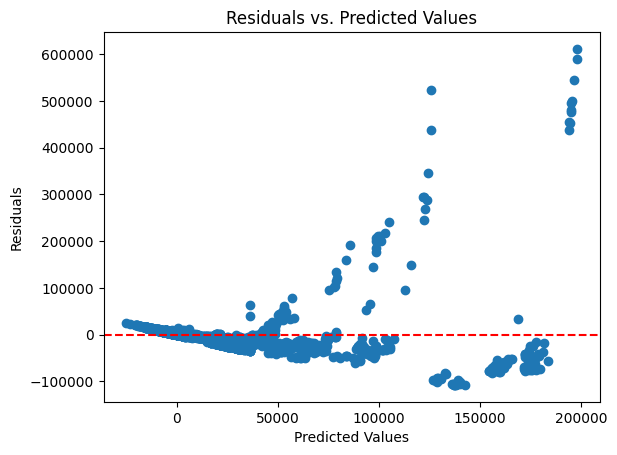

In [19]:
from sklearn.metrics import mean_squared_error, r2_score

# Predicting on the test set using the lasso pipeline
y_pred = lasso_pipeline.predict(X_test)

# Calculating metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Printing the results
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

# Plotting residuals
import matplotlib.pyplot as plt

residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

In [20]:
import statsmodels.api as sm

# Adding a constant to the model (statsmodels doesn't add a constant by default)
X_train_sm = sm.add_constant(X_train)  # Adding a constant for the intercept

# Fitting the model
model = sm.OLS(y_train, X_train_sm).fit()

# Printing the summary
model_summary = model.summary()
model_summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Dollar Sales   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.419
Method:                 Least Squares   F-statistic:                     129.4
Date:                Sun, 28 Apr 2024   Prob (F-statistic):               0.00
Time:                        20:46:00   Log-Likelihood:            -1.8969e+05
No. Observations:               15848   AIC:                         3.796e+05
Df Residuals:                   15758   BIC:                         3.803e+05
Df Model:                          89                                         
Covariance Type:            nonrobust                                         
================================================================================================================================================================================
                                                                                                                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
const                                                                                                        -4995.3562   3655.798     -1.366      0.172   -1.22e+04    2170.426
Total Ounces                                                                                                  -783.9880    326.736     -2.399      0.016   -1424.429    -143.547
UPC 13 digit                                                                                                   1.84e-08   2.32e-09      7.925      0.000    1.38e-08    2.29e-08
Price per Unit                                                                                                 -93.7802    374.067     -0.251      0.802    -826.994     639.434
ACV Weighted Distribution                                                                                     1388.8406     76.180     18.231      0.000    1239.519    1538.162
Geography_Great Lakes - Standard - Multi Outlet + Conv                                                        3262.3009   1433.432      2.276      0.023     452.610    6071.991
Geography_Mid-South - Standard - Multi Outlet + Conv                                                          6828.9453   1385.262      4.930      0.000    4113.673    9544.218
Geography_Northeast - Standard - Multi Outlet + Conv                                                          8381.0703   1370.192      6.117      0.000    5695.336    1.11e+04
Geography_Plains - Standard - Multi Outlet + Conv                                                             -714.3044   1534.084     -0.466      0.641   -3721.285    2292.677
Geography_South Central - Standard - Multi Outlet + Conv                                                      1153.8485   1511.211      0.764      0.445   -1808.298    4115.995
Geography_Southeast - Standard - Multi Outlet + Conv                                                          3785.6838   1442.921      2.624      0.009     957.394    6613.973
Geography_Total US - Multi Outlet + Conv                                                                      3.972e+04   1323.126     30.017      0.000    3.71e+04    4.23e+04
Geography_West - Standard - Multi Outlet + Conv                                                               1553.2057   1432.275      1.084      0.278   -1254.217    4360.628
Product_DR PRAEGERS FROZEN CHICKEN PLANT BASED CHICKEN SUBSTITUTE TENDER 12 OZ - 0080868260301                7416.9874   3017.518      2.458      0.014    1502.306    1.33e+04
Product_DR PRAEGERS FROZEN REGULAR MEAT SUBSTITUTE BURGER 10 OZ - 00808680

In [21]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LinearRegression

# Setting up the linear regression model
lr = LinearRegression()

# Setting up backward elimination using Sequential Feature Selector
sfs = SFS(lr,
          k_features=(1, len(X_train.columns)),  # Minimum and maximum number of features
          forward=False,  # Set to False for backward elimination
          floating=False,
          scoring='r2',
          cv=5)

# Fit SFS
sfs = sfs.fit(X_train, y_train)

# Outputting the selected features
selected_features = sfs.k_feature_names_
selected_features

('Total Ounces',
 'UPC 13 digit',
 'Price per Unit',
 'ACV Weighted Distribution',
 'Geography_Great Lakes - Standard - Multi Outlet + Conv',
 'Geography_Mid-South - Standard - Multi Outlet + Conv',
 'Geography_Northeast - Standard - Multi Outlet + Conv',
 'Geography_Plains - Standard - Multi Outlet + Conv',
 'Geography_South Central - Standard - Multi Outlet + Conv',
 'Geography_Southeast - Standard - Multi Outlet + Conv',
 'Geography_Total US - Multi Outlet + Conv',
 'Geography_West - Standard - Multi Outlet + Conv',
 'Product_DR PRAEGERS FROZEN CHICKEN PLANT BASED CHICKEN SUBSTITUTE TENDER 12 OZ - 0080868260301',
 'Product_DR PRAEGERS FROZEN REGULAR MEAT SUBSTITUTE BURGER 10 OZ - 0080868008001',
 'Product_DR PRAEGERS FROZEN REGULAR MEAT SUBSTITUTE BURGER 8 OZ - 0080868029071',
 'Product_DR PRAEGERS FROZEN REGULAR POULTRY SUBSTITUTE TENDER 8 OZ - 0080868260001',
 'Product_GARDEIN FROZEN ITALIAN MEAT SUBSTITUTE PATTY 8 OZ - 0842234002241',
 'Product_GARDEIN FROZEN ORIGINAL MEAT SUBSTI

In [23]:
selected_features

('Total Ounces',
 'UPC 13 digit',
 'Price per Unit',
 'ACV Weighted Distribution',
 'Geography_Great Lakes - Standard - Multi Outlet + Conv',
 'Geography_Mid-South - Standard - Multi Outlet + Conv',
 'Geography_Northeast - Standard - Multi Outlet + Conv',
 'Geography_Plains - Standard - Multi Outlet + Conv',
 'Geography_South Central - Standard - Multi Outlet + Conv',
 'Geography_Southeast - Standard - Multi Outlet + Conv',
 'Geography_Total US - Multi Outlet + Conv',
 'Geography_West - Standard - Multi Outlet + Conv',
 'Product_DR PRAEGERS FROZEN CHICKEN PLANT BASED CHICKEN SUBSTITUTE TENDER 12 OZ - 0080868260301',
 'Product_DR PRAEGERS FROZEN REGULAR MEAT SUBSTITUTE BURGER 10 OZ - 0080868008001',
 'Product_DR PRAEGERS FROZEN REGULAR MEAT SUBSTITUTE BURGER 8 OZ - 0080868029071',
 'Product_DR PRAEGERS FROZEN REGULAR POULTRY SUBSTITUTE TENDER 8 OZ - 0080868260001',
 'Product_GARDEIN FROZEN ITALIAN MEAT SUBSTITUTE PATTY 8 OZ - 0842234002241',
 'Product_GARDEIN FROZEN ORIGINAL MEAT SUBSTI

In [25]:
import statsmodels.api as sm

# Extracting the selected features
X_train_selected = X_train[list(selected_features)]

# Adding a constant to the features
X_train_selected = sm.add_constant(X_train_selected)

# Fitting the linear regression model
model = sm.OLS(y_train, X_train_selected).fit()

# Printing the summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           Dollar Sales   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.419
Method:                 Least Squares   F-statistic:                     155.7
Date:                Sun, 28 Apr 2024   Prob (F-statistic):               0.00
Time:                        21:11:29   Log-Likelihood:            -1.8969e+05
No. Observations:               15848   AIC:                         3.795e+05
Df Residuals:                   15773   BIC:                         3.801e+05
Df Model:                          74                                         
Covariance Type:            nonrobust                                         
                                                                                                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------